# Análise Descritiva: Identificação de Potenciais Clientes para "*********"

## Sobre a Empresa
A "********" é especializada no comércio e manutenção de máquinas de costura, oferecendo soluções completas que incluem:
- Venda de máquinas de costura seminovas;
- Serviços de manutenção preventiva e corretiva;
- Comercialização de peças e acessórios;
- Suporte técnico especializado;

## Objetivo da Análise
Este estudo tem como principal objetivo desenvolver um modelo descritivo para identificar bairros com maiores quantidades de empresas que possuam máquinas de costura, baseando-se em dados cadastrais públicos disponíveis.

## Limitações da Base de Dados
É importante destacar que a análise apresenta algumas limitações devido à natureza dos dados disponíveis:
1. Ausência de informações sobre o porte das empresas;
2. Falta de dados financeiros que poderiam indicar capacidade de investimento;
3. Ausência de informações sobre equipamentos já existentes;
4. Sem histórico de compras ou manutenções anteriores;

## Dados Disponíveis para Análise
- CNPJ (Básico, Ordem e DV - digito verificador);
- Situação cadastral da empresa;
- Data de início das atividades;
- Descrição do CNAE (Classificação Nacional de Atividades Econômicas);
- Localização (Bairro, UF e Município);

## Análises a Serem Realizadas

### 1. Análise Exploratória dos Dados
- Verificação da qualidade e completude dos dados disponíveis;
- Análise da distribuição das empresas por CNAE;
- Estatísticas descritivas das principais variáveis;

### 2. Análise Geográfica
- Distribuição das empresas por estado e município;
- Identificação de concentrações regionais relevantes;
- Mapeamento de áreas com maior potencial;

### 3. Recomendações Estratégicas
- Identificação dos perfis mais propensos a necessitar dos serviços;
- Recomendações para abordagem comercial baseada nos insights obtidos;

## Metodologia
A análise será conduzida utilizando Python e suas principais bibliotecas:
- Pandas para manipulação de dados;
- Matplotlib para visualizações;
- Datetime para conversão de dados do tipo string para datetime;

## Fontes
- Cadastro Nacional da Pessoa Jurídica - Dados - https://arquivos.receitafederal.gov.br/dados/cnpj/dados_abertos_cnpj/2024-10/
- Cadastro Nacional da Pessoa Jurídica - Layout dos arquivos - https://arquivos.receitafederal.gov.br/dados/cnpj/LAYOUT_DADOS_ABERTOS_CNPJ.pdf

In [4]:
# Importação das bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [6]:
# Carregamento dos dados
df = pd.read_csv("estabelecimentos_5kk.csv", encoding="utf-8", sep=';')

In [8]:
# Verificação da qualidade e completude dos dados disponíveis - Amostra inicial dos dados
display(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5483678 entries, 0 to 5483677
Data columns (total 9 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   CNPJ_BASICO            int64 
 1   CNPJ_ORDEM             int64 
 2   CNPJ_DV                int64 
 3   SITUACAO_CADASTRAL     object
 4   DATA_INICIO_ATIVIDADE  object
 5   CNAE_DESCRICAO         object
 6   BAIRRO                 object
 7   UF                     object
 8   MUNICIPIO              object
dtypes: int64(3), object(6)
memory usage: 376.5+ MB


None

,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,SITUACAO_CADASTRAL,DATA_INICIO_ATIVIDADE,CNAE_DESCRICAO,BAIRRO,UF,MUNICIPIO
0,972329,1,14,NaN,14/12/1995,Comércio varejista de artigos do vestuário e a...,CENTRO,RS,CACEQUI
1,5991672,1,20,BAIXADA,11/11/2003,Comércio varejista de artigos do vestuário e a...,ENGENHO V.DA FEDERAC,BA,SALVADOR
2,2600230,1,17,NaN,17/06/1998,Comércio varejista de artigos do vestuário e a...,JARDIM YARA,MG,POUSO ALEGRE
3,5991718,1,0,BAIXADA,10/11/2003,Comércio varejista de artigos do vestuário e a...,CENTRO,GO,CERES
4,24570350,2,32,NaN,17/06/1999,Comércio varejista de artigos do vestuário e a...,COMERCIO,PA,BELEM


In [5]:
# Verificação da qualidade e completude dos dados disponíveis - Análise de valores ausentes

missing_values = pd.DataFrame({
    'Total Nulos': df.isnull().sum(), 
    'Porcentagem Nulos (%)': (df.isnull().sum() / len(df) * 100).round(5)
})
missing_values = missing_values.sort_values('Porcentagem Nulos (%)', ascending=False) 
missing_values = missing_values[missing_values['Total Nulos'] > 0] 
missing_values 

,Total Nulos,Porcentagem Nulos (%)
SITUACAO_CADASTRAL,2793097,50.93474
BAIRRO,2,0.00004


In [10]:
# Estatísticas descritivas das principais variáveis - Verificar consistência da Situação Cadastral
print("Valores em SITUACAO_CADASTRAL originais:")
display(df['SITUACAO_CADASTRAL'].value_counts())
print("\n")

#Cria uma nova categoria para valores ausentes
df['SITUACAO_CADASTRAL'] = df['SITUACAO_CADASTRAL'].fillna('ATIVA')

# Estatísticas descritivas das principais variáveis - Verificar consistência da Situação Cadastral
print("Valores em SITUACAO_CADASTRAL após tratamento:")
display(df['SITUACAO_CADASTRAL'].value_counts())

Valores em SITUACAO_CADASTRAL originais:


SITUACAO_CADASTRAL
BAIXADA    2680295
NULA         10286
Name: count, dtype: int64



Valores em SITUACAO_CADASTRAL após tratamento:


SITUACAO_CADASTRAL
ATIVA      2793097
BAIXADA    2680295
NULA         10286
Name: count, dtype: int64

In [12]:
# Verificação da qualidade e completude dos dados disponíveis - Análise de valores ausentes
missing_values = pd.DataFrame({
    'Total Nulos': df.isnull().sum(),
    'Porcentagem Nulos (%)': (df.isnull().sum() / len(df) * 100).round(5)
})
missing_values = missing_values.sort_values('Porcentagem Nulos (%)', ascending=False)
missing_values = missing_values[missing_values['Total Nulos'] > 0]
missing_values

,Total Nulos,Porcentagem Nulos (%)
BAIRRO,2,0.00004


In [14]:
# Converte DATA_INICIO_ATIVIDADE em data e hora e extrai em décadas
df['DATA_INICIO_ATIVIDADE'] = pd.to_datetime(df['DATA_INICIO_ATIVIDADE'], dayfirst=True)

In [16]:
# Dataframe após tratamento de DATA_INICIO_ATIVIDADE e SITUACAO_CADASTRAL sem valores
display(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5483678 entries, 0 to 5483677
Data columns (total 9 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   CNPJ_BASICO            int64         
 1   CNPJ_ORDEM             int64         
 2   CNPJ_DV                int64         
 3   SITUACAO_CADASTRAL     object        
 4   DATA_INICIO_ATIVIDADE  datetime64[ns]
 5   CNAE_DESCRICAO         object        
 6   BAIRRO                 object        
 7   UF                     object        
 8   MUNICIPIO              object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 376.5+ MB


None

,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,SITUACAO_CADASTRAL,DATA_INICIO_ATIVIDADE,CNAE_DESCRICAO,BAIRRO,UF,MUNICIPIO
0,972329,1,14,ATIVA,1995-12-14,Comércio varejista de artigos do vestuário e a...,CENTRO,RS,CACEQUI
1,5991672,1,20,BAIXADA,2003-11-11,Comércio varejista de artigos do vestuário e a...,ENGENHO V.DA FEDERAC,BA,SALVADOR
2,2600230,1,17,ATIVA,1998-06-17,Comércio varejista de artigos do vestuário e a...,JARDIM YARA,MG,POUSO ALEGRE
3,5991718,1,0,BAIXADA,2003-11-10,Comércio varejista de artigos do vestuário e a...,CENTRO,GO,CERES
4,24570350,2,32,ATIVA,1999-06-17,Comércio varejista de artigos do vestuário e a...,COMERCIO,PA,BELEM


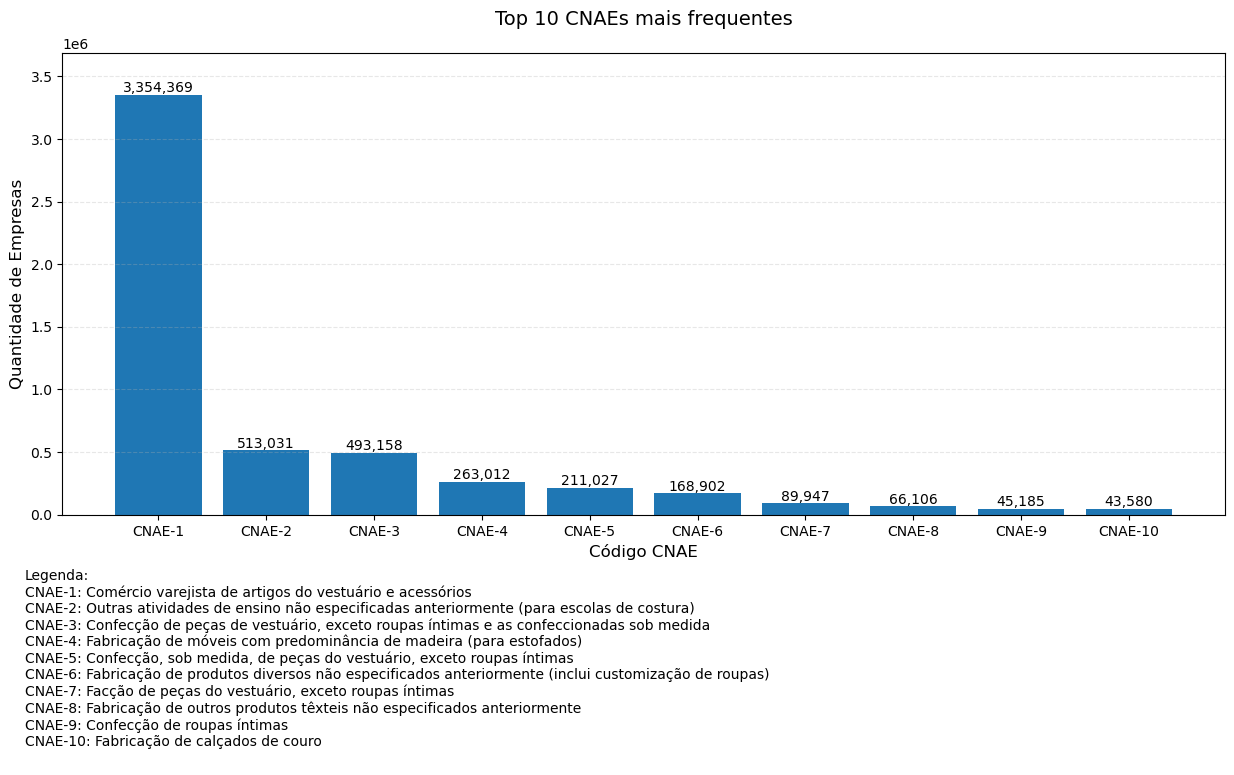

In [18]:
# Estatísticas descritivas das principais variáveis - Análise da distribuição das empresas por CNAE;
cnae_counts = df['CNAE_DESCRICAO'].value_counts().head(10)

# Cria rótulos simplificados para o eixo x
alias = [f'CNAE-{i+1}' for i in range(10)]

# Cria a visualização
plt.figure(figsize=(15, 6))

# Cria barras verticais
bars = plt.bar(alias, cnae_counts)

# adiciona e personaliza o título e os rótulos dos eixos
plt.title('Top 10 CNAEs mais frequentes', fontsize=14, pad=20)
plt.xlabel('Código CNAE', fontsize=12)
plt.ylabel('Quantidade de Empresas', fontsize=12) 


# Adiciona valores no topo de cada barra 
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, 
             f'{int(height):,}', 
             ha='center', va='bottom')

# Define o limite do eixo y para acomodar rótulos
plt.ylim(0, max(cnae_counts) * 1.1)

# Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Cria um texto de legenda
legend_text = 'Legenda:\n'
for i, cnae_desc in enumerate(cnae_counts.index):
    legend_text += f'CNAE-{i+1}: {cnae_desc}\n'

# Adiciona texto de legenda abaixo do gráfico
plt.figtext(0.1, 0.02, legend_text, fontsize=10, va='top', ha='left')

# Mosrtra o gráfico
plt.show()

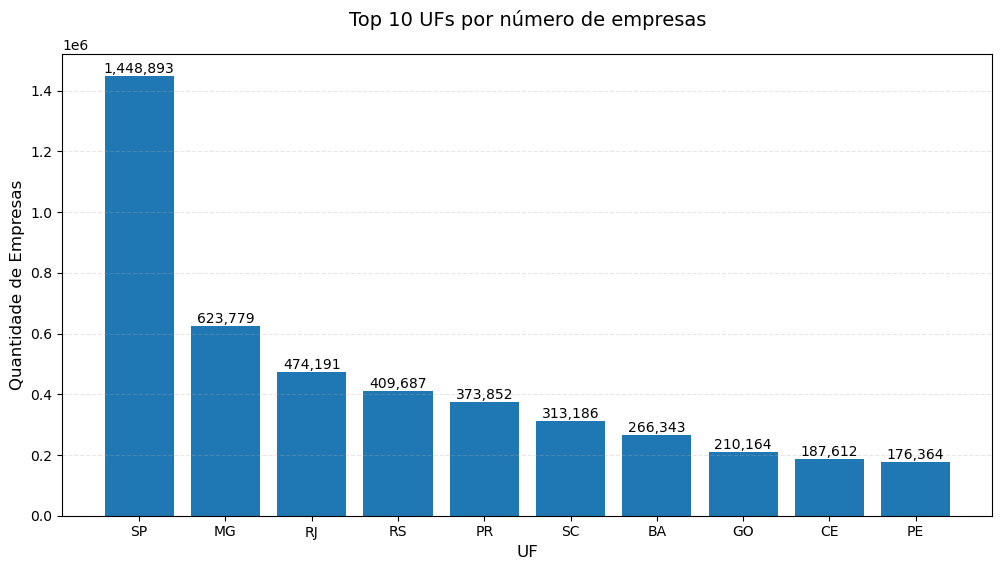

In [21]:
# Estatísticas descritivas das principais variáveis - Análise da distribuição das empresas por UF;
# Agrupar por UF e contar ocorrências
uf_counts = df['UF'].value_counts().head(10)

# Cria a visualização
plt.figure(figsize=(12, 6))

bars = plt.bar(uf_counts.index, uf_counts.values) 

plt.title('Top 10 UFs por número de empresas', fontsize=14, pad=20) 
plt.xlabel('UF', fontsize=12) 
plt.ylabel('Quantidade de Empresas', fontsize=12) 

# Adiciona valores no topo de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}',
             ha='center', va='bottom')

# configurar os titulos do eixo x para melhor legibilidade
plt.xticks()

# Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Mosrtra o gráfico
plt.show()

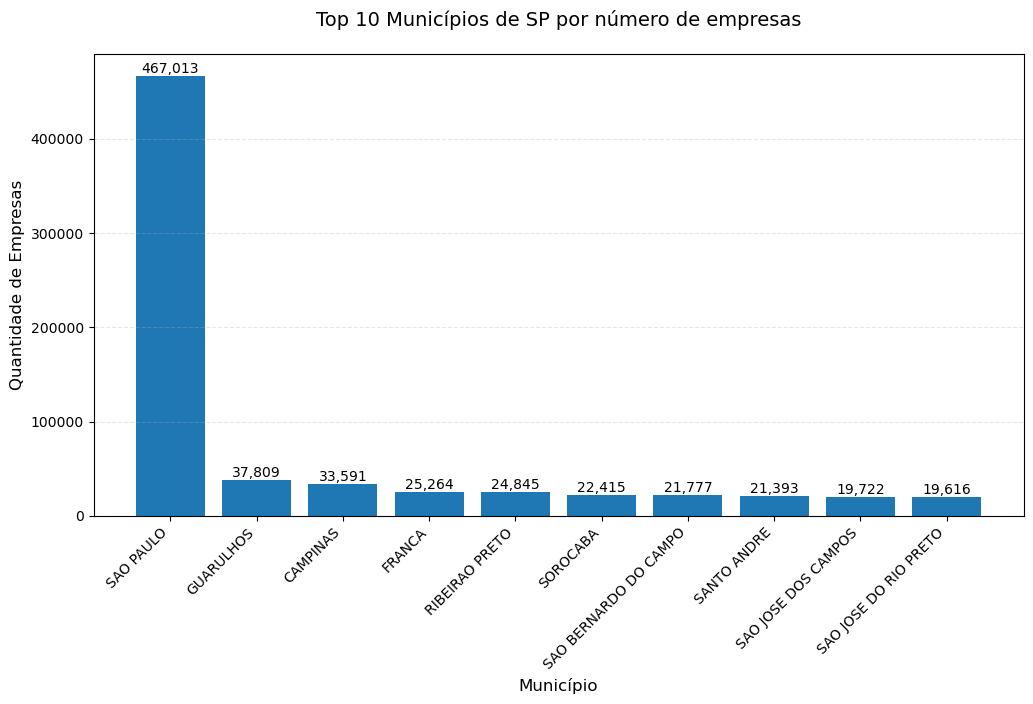

In [20]:
# Filtra por estado SP e obtém os 10 municipios com mais empresas
sp_municipios = df[df['UF'] == 'SP']['MUNICIPIO'].value_counts().head(10)

# Cria a visualização
plt.figure(figsize=(12, 6))
bars = plt.bar(sp_municipios.index, sp_municipios.values)

plt.title('Top 10 Municípios de SP por número de empresas', fontsize=14, pad=20)
plt.xlabel('Município', fontsize=12)
plt.ylabel('Quantidade de Empresas', fontsize=12)

# Adiciona valores no topo de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}',
             ha='center', va='bottom')

# Rotaciona os titulos do eixo X para melhorar legibilidade
plt.xticks(rotation=45, ha='right')

# Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Mosrtra o gráfico
plt.show()

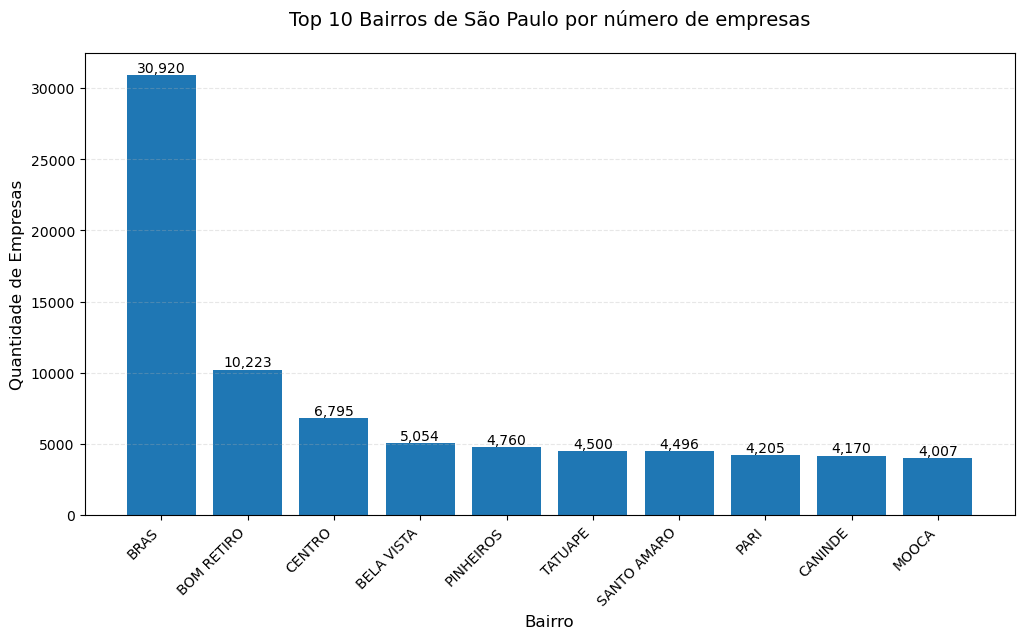

In [25]:
# Filtra pelo estado de SP e cidade de São Paulo para obter os 10 bairros com mais empresas
sp_bairros = df[(df['UF'] == 'SP') & 
                (df['MUNICIPIO'] == 'SAO PAULO')]['BAIRRO'].value_counts().head(10)

# Cria a visualização
plt.figure(figsize=(12, 6))
bars = plt.bar(sp_bairros.index, sp_bairros.values)

plt.title('Top 10 Bairros de São Paulo por número de empresas', fontsize=14, pad=20)
plt.xlabel('Bairro', fontsize=12)
plt.ylabel('Quantidade de Empresas', fontsize=12)

# Adiciona valores no topo de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}',
             ha='center', va='bottom')

# Rotaciona os titulos do eixo X para melhorar legibilidade
plt.xticks(rotation=45, ha='right')

# Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Mosrtra o gráfico
plt.show()

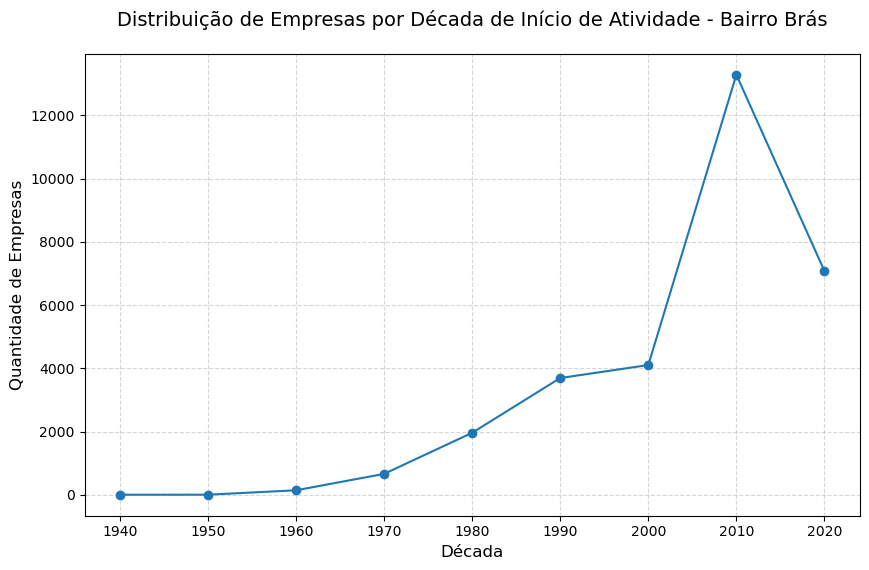

In [22]:
# Filtra por bairro Brás na cidade de São Paulo
bras_df = df.loc[(df['UF'] == 'SP') & 
                 (df['MUNICIPIO'] == 'SAO PAULO') & 
                 (df['BAIRRO'] == 'BRAS')].copy()

# Converte DATA_INICIO_ATIVIDADE do tipo string para datetime e calcula as décadas
bras_df['DECADA'] = (bras_df['DATA_INICIO_ATIVIDADE'].dt.year // 10 * 10).astype(str)

# Contabiliza a quantidade de companias por década
decade_counts = bras_df['DECADA'].value_counts().sort_index()

# Cria a visualização
plt.figure(figsize=(10, 6))
decade_counts.plot(marker='o')

# Adiciona rótulos
plt.title('Distribuição de Empresas por Década de Início de Atividade - Bairro Brás', fontsize=14, pad=20)
plt.xlabel('Década', fontsize=12)
plt.ylabel('Quantidade de Empresas', fontsize=12)

# # Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Mosrtra o gráfico
plt.show()

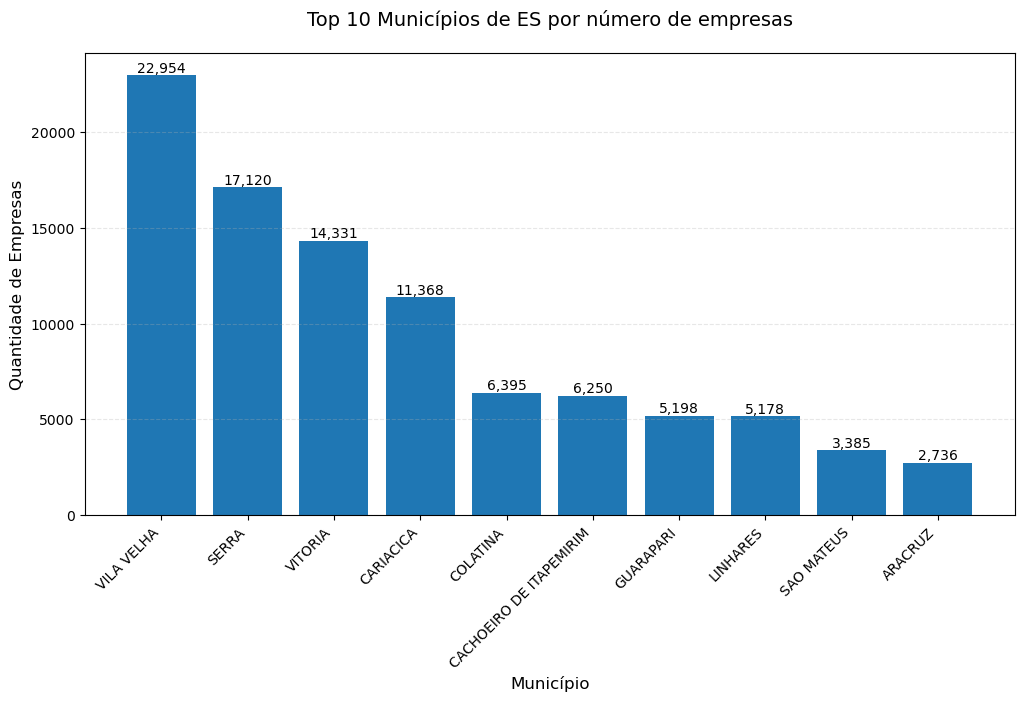

In [24]:
# Filtra por estado ES e obtém os 10 municipios com mais empresas
es_municipios = df[df['UF'] == 'ES']['MUNICIPIO'].value_counts().head(10)

# Cria a visualização
plt.figure(figsize=(12, 6))
bars = plt.bar(es_municipios.index, es_municipios.values)

plt.title('Top 10 Municípios de ES por número de empresas', fontsize=14, pad=20)
plt.xlabel('Município', fontsize=12)
plt.ylabel('Quantidade de Empresas', fontsize=12)

# Adiciona valores no topo de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}',
             ha='center', va='bottom')

# Rotaciona os titulos do eixo X para melhorar legibilidade
plt.xticks(rotation=45, ha='right')

# Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Mosrtra o gráfico
plt.show()

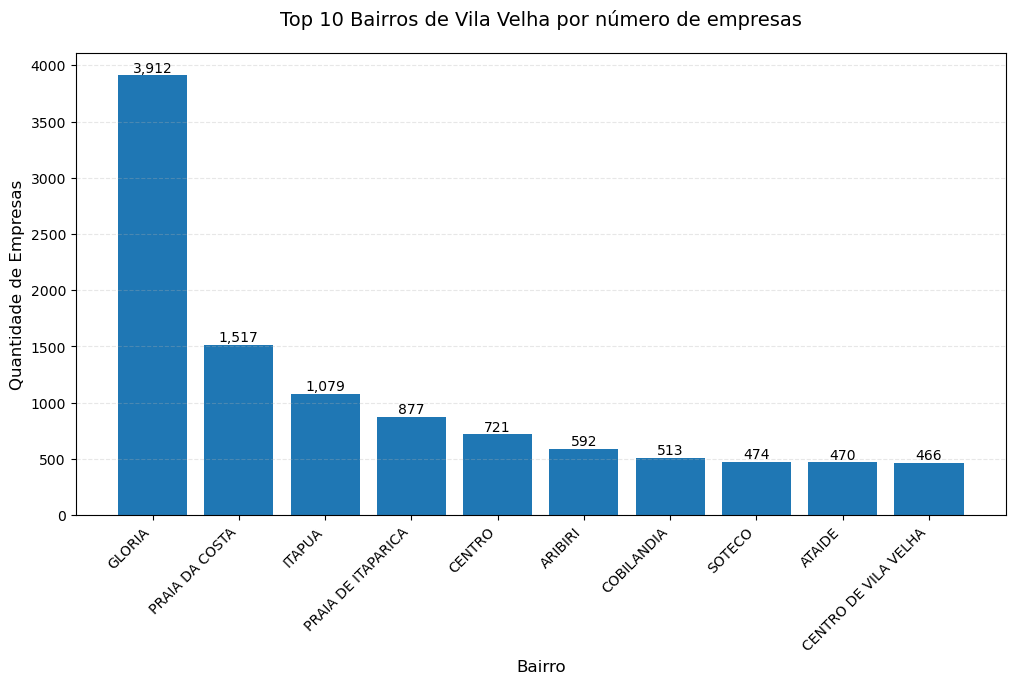

In [29]:
# Filtra por estado ES e cidade Vila Velha para obter os 10 bairros com mais empresas
es_bairros = df[(df['UF'] == 'ES') & 
                (df['MUNICIPIO'] == 'VILA VELHA')]['BAIRRO'].value_counts().head(10)

# Cria a visualização
plt.figure(figsize=(12, 6))
bars = plt.bar(es_bairros.index, es_bairros.values)

plt.title('Top 10 Bairros de Vila Velha por número de empresas', fontsize=14, pad=20)
plt.xlabel('Bairro', fontsize=12)
plt.ylabel('Quantidade de Empresas', fontsize=12)

# Adiciona valores no topo de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}',
             ha='center', va='bottom')

# Rotaciona os titulos do eixo X para melhorar legibilidade
plt.xticks(rotation=45, ha='right')

# Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Mosrtra o gráfico
plt.show()

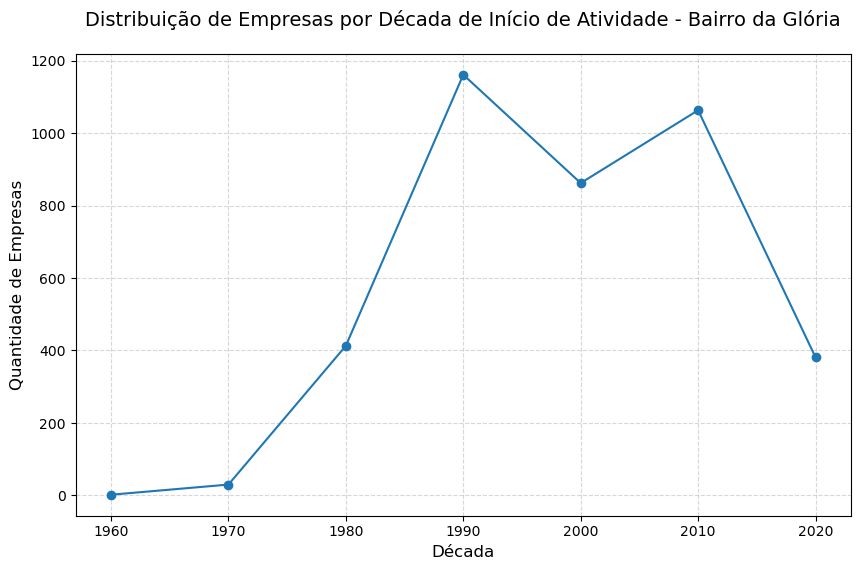

In [26]:
# Filtra por bairro da Glória na cidade de Vila Velha
gloria_df = df.loc[(df['UF'] == 'ES') & 
                 (df['MUNICIPIO'] == 'VILA VELHA') & 
                 (df['BAIRRO'] == 'GLORIA')].copy()

# Converte DATA_INICIO_ATIVIDADE do tipo string para datetime e calcula as décadas
gloria_df['DECADA'] = (gloria_df['DATA_INICIO_ATIVIDADE'].dt.year // 10 * 10).astype(str)

# Contabiliza a quantidade de companias por decada
decade_counts = gloria_df['DECADA'].value_counts().sort_index()

# Cria a visualização
plt.figure(figsize=(10, 6))
decade_counts.plot(marker='o')

# Adiciona rótulos
plt.title('Distribuição de Empresas por Década de Início de Atividade - Bairro da Glória', fontsize=14, pad=20)
plt.xlabel('Década', fontsize=12)
plt.ylabel('Quantidade de Empresas', fontsize=12)

# # Adiciona uma grade para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Mosrtra o gráfico
plt.show()

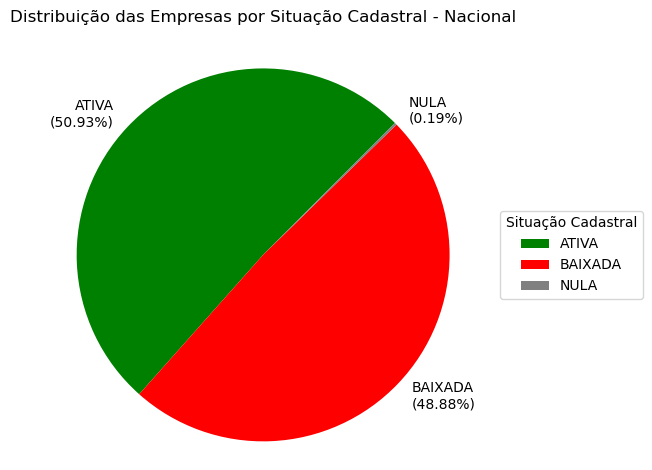

In [33]:
# Calculando a contagem e percentual de cada situação
situacao_counts = df['SITUACAO_CADASTRAL'].value_counts()
total = len(df)
situacao_pct = (situacao_counts / total * 100).round(2)

# Cores para cada situação
cores = ['GREEN', 'RED', 'GRAY']  # Verde para Ativa, Vermelho para Baixada, Cinza para Nula

# Criando o gráfico
plt.pie(situacao_pct, 
        labels=[f'{situacao}\n({pct}%)' for situacao, pct in situacao_pct.items()],
        colors=cores,
        autopct='',
        startangle=45)

plt.title('Distribuição das Empresas por Situação Cadastral - Nacional', pad=20)

# Adicionando legenda
plt.legend(situacao_counts.index, 
          title='Situação Cadastral',
          loc='center left', 
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.axis('equal') #Ajusta a escala dos eixos do um gráfico, "equal" garantindo que a proporção entre as unidades dos eixos seja igual.

plt.tight_layout()
plt.show()

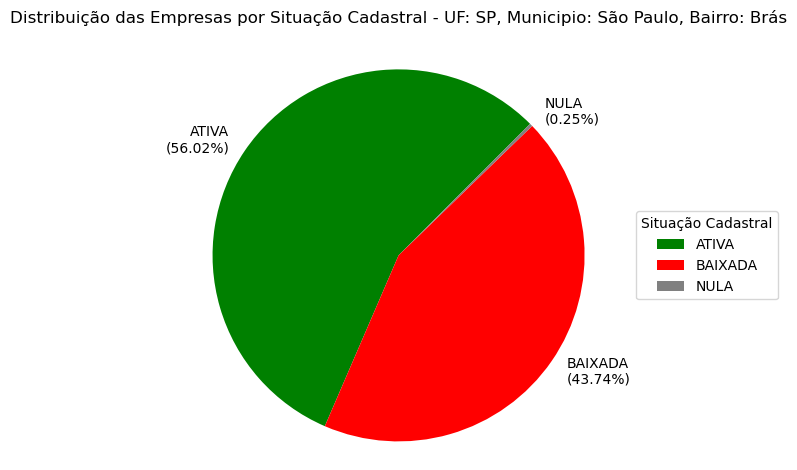

In [28]:
# Calculando a contagem e percentual de cada situação
situacao_counts = bras_df['SITUACAO_CADASTRAL'].value_counts()
total = len(bras_df)
situacao_pct = (situacao_counts / total * 100).round(2)

# Cores para cada situação
cores = ['GREEN', 'RED', 'GRAY']  # Verde para Ativa, Vermelho para Baixada, Cinza para Nula

# Criando o gráfico
plt.pie(situacao_pct, 
        labels=[f'{situacao}\n({pct}%)' for situacao, pct in situacao_pct.items()],
        colors=cores,
        autopct='',
        startangle=45)

plt.title('Distribuição das Empresas por Situação Cadastral - UF: SP, Municipio: São Paulo, Bairro: Brás', pad=20) 

# Adicionando legenda
plt.legend(situacao_counts.index, 
          title='Situação Cadastral',
          loc='center left',
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.axis('equal')
plt.tight_layout()
plt.show()

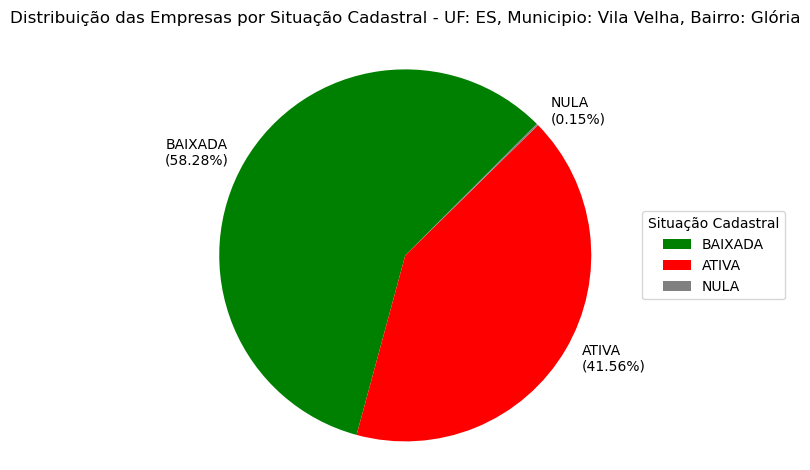

In [36]:
# Calculando a contagem e percentual de cada situação
situacao_counts = gloria_df['SITUACAO_CADASTRAL'].value_counts()
total = len(gloria_df)
situacao_pct = (situacao_counts / total * 100).round(2)

# Cores para cada situação
cores = ['GREEN', 'RED', 'GRAY']  # Verde para Ativa, Vermelho para Baixada, Cinza para Nula

# Criando o gráfico
plt.pie(situacao_pct, 
        labels=[f'{situacao}\n({pct}%)' for situacao, pct in situacao_pct.items()],
        colors=cores,
        autopct='',
        startangle=45)

plt.title('Distribuição das Empresas por Situação Cadastral - UF: ES, Municipio: Vila Velha, Bairro: Glória', pad=20)

# Adicionando legenda
plt.legend(situacao_counts.index, 
          title='Situação Cadastral',
          loc='center left',
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.axis('equal')
plt.tight_layout()
plt.show()

### 3. Recomendações Estratégicas

Com base na análise realizada, identificamos as seguintes oportunidades de negociação:


- **Prestação de serviços de manutenção e venda de máquinas (usadas ou novas)**: Empresas que iniciaram suas atividades na década de **2020** e que possuem o status "**ATIVA**". Essas empresas podem ter maior necessidade de manutenção ou interesse em adquirir máquinas.

- **Compra de máquinas usadas para manutenção e revenda futura**: Empresas que estão no mercado há mais de **7 anos** com status "**ATIVA**" ou aquelas com status "**BAIXADA**". Empresas com status "**BAIXADA**" podem ter máquinas em bom estado que necessitem de reparos e, consequentemente, poderiam ser adquiridas a preços vantajosos, permitindo lucratividade em uma futura revenda.
<br>

**Nota:**

Essa análise é descritiva e visa apenas organizar, resumir e compreender os dados disponíveis. Ela não garante que as empresas mencionadas aceitarão negociar com a "*******". Avaliações adicionais e abordagens diretas são recomendadas para validar as oportunidades levantadas.